In [1]:
# imported basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# mount drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Get the data set
df = pd.read_csv('/content/drive/My Drive/1 - Internship/Project/Airline Ticket Pricing Analysis/airlines_flights_data.csv')

In [4]:
df

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [5]:
# row and columns
df.shape

(300153, 12)

In [6]:
# Remove the 'index' column

df.drop( columns = 'index', inplace = True)

In [7]:
# Information of the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [8]:
# Description of the data
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [9]:
# check for the missing values in any column
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [10]:
# Checking the duplicate value

df.duplicated().sum()

np.int64(0)

# EDA

In [11]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [12]:
# Checking the unique value in airlines


df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

Text(0.5, 1.0, 'Flights per Airlines')

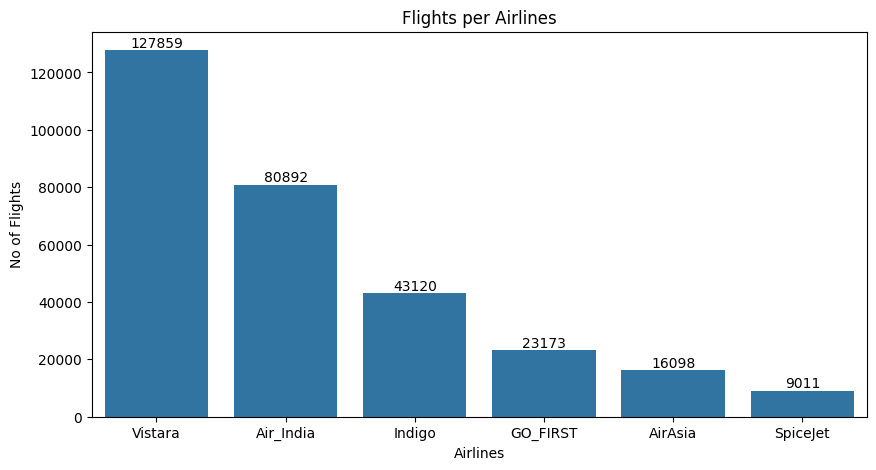

In [13]:
# Number of flights per airlines

plt.figure(figsize=(10,5))
ax = sns.barplot(x=df['airline'].value_counts().index, y=df['airline'].value_counts().values )
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Airlines")
plt.ylabel("No of Flights")
plt.title("Flights per Airlines")

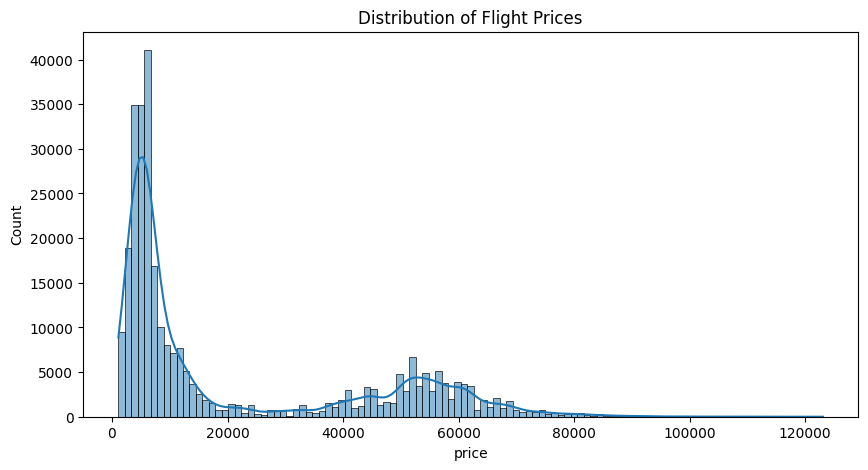

In [14]:
# Distribution of Flight Prices

plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True )
plt.title("Distribution of Flight Prices")
plt.show()

In [15]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [16]:
# Unique values in the source city

df['source_city'].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai'],
      dtype=object)

Text(0.5, 1.0, 'Flights per Source City')

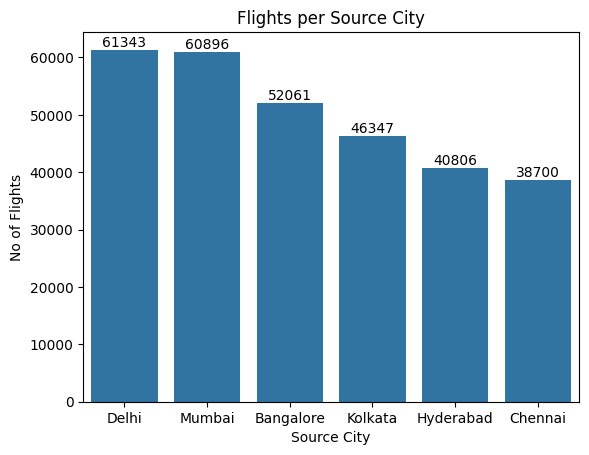

In [17]:
# Flights per Source City

ax = sns.barplot(x=df['source_city'].value_counts().index, y=df['source_city'].value_counts().values)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Source City")
plt.ylabel("No of Flights")
plt.title("Flights per Source City")

In [18]:
# Unique values in the destination city

df['destination_city'].unique()

array(['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi'],
      dtype=object)

Text(0.5, 1.0, 'Flights per Destination City')

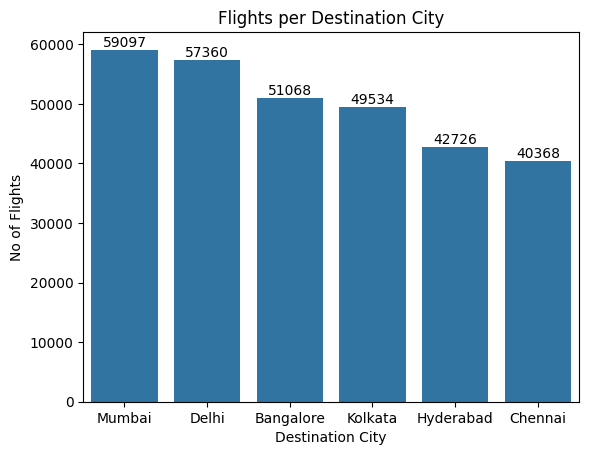

In [19]:
# Flights per Destination City

ax = sns.barplot(x=df['destination_city'].value_counts().index, y=df['destination_city'].value_counts().values)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Destination City")
plt.ylabel("No of Flights")
plt.title("Flights per Destination City")

In [20]:
# Unique values in stops

df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

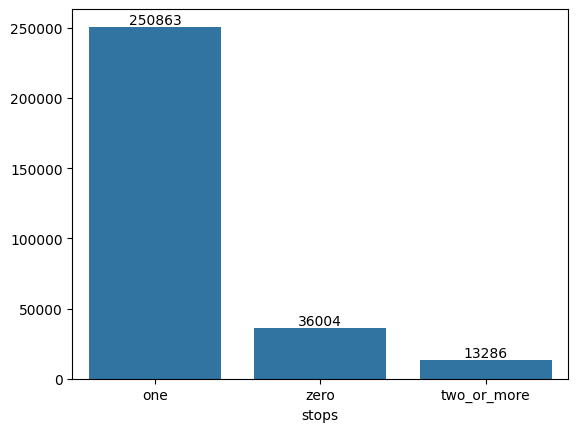

In [21]:
# Number of flights per stop

ax = sns.barplot(x=df['stops'].value_counts().index, y=df['stops'].value_counts().values)
for container in ax.containers:
    ax.bar_label(container)

In [22]:
# Unique values in departure time

df['departure_time'].unique()

array(['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night',
       'Late_Night'], dtype=object)

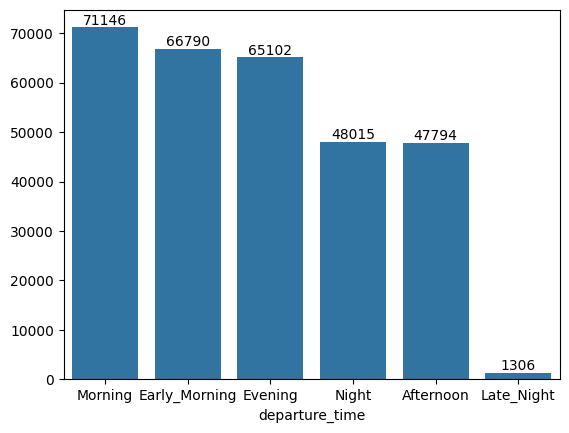

In [23]:
# Number of fligths per departure time

ax = sns.barplot(x=df['departure_time'].value_counts().index, y=df['departure_time'].value_counts().values)
for container in ax.containers:
    ax.bar_label(container)

In [24]:
# Unique values in Arrival time

df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

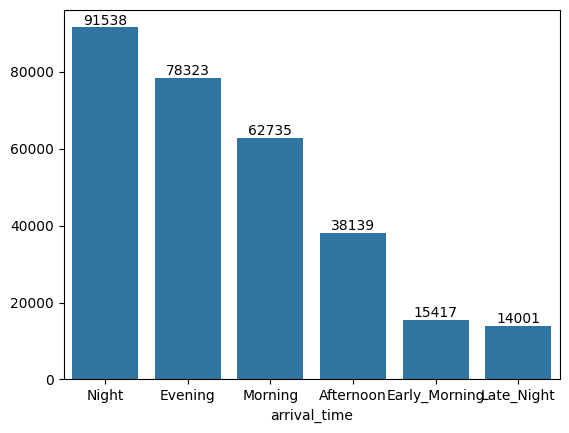

In [25]:
# Number of fligths per Arrival time

ax = sns.barplot(x=df['arrival_time'].value_counts().index, y=df['arrival_time'].value_counts().values)
for container in ax.containers:
    ax.bar_label(container)

In [26]:
# Unique values in class

df['class'].unique()

array(['Economy', 'Business'], dtype=object)

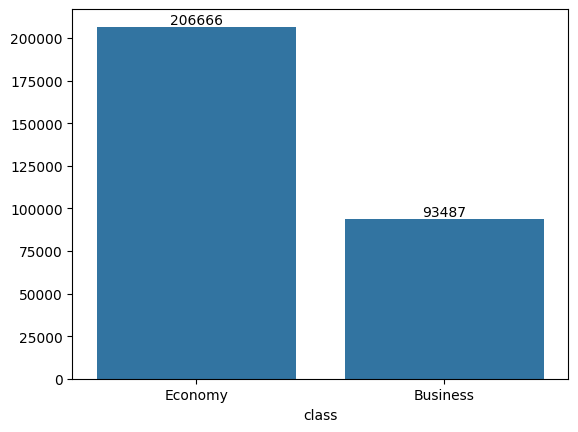

In [27]:
# Number of flights in class

ax = sns.barplot(x=df['class'].value_counts().index, y=df['class'].value_counts().values)
for container in ax.containers:
    ax.bar_label(container)

In [28]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


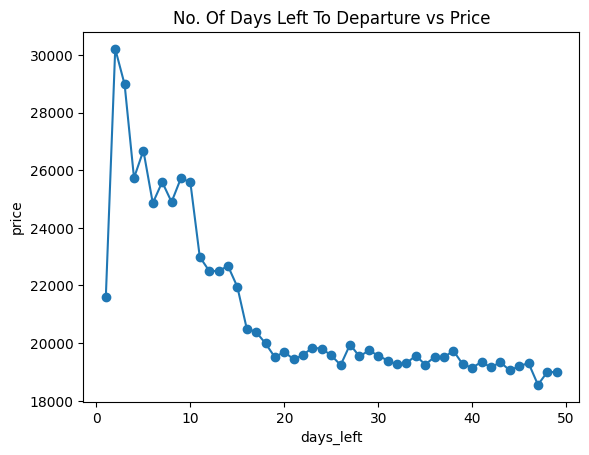

In [29]:
# Price vs Day left line

price_by_daysleft=df.groupby('days_left')['price'].mean().reset_index()
plt.title('No. Of Days Left To Departure vs Price')
plt.scatter(x=price_by_daysleft['days_left'],y=price_by_daysleft['price'])
sns.lineplot(x=price_by_daysleft['days_left'],y=price_by_daysleft['price'])
plt.show()

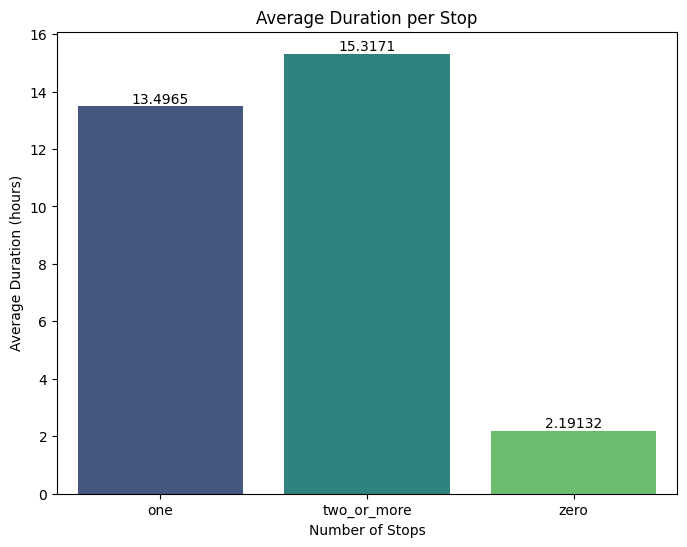

In [30]:
# Average time taken to reach destination per stop

avg_duration = df.groupby('stops')['duration'].mean().reset_index()

plt.figure(figsize=(8,6))
ax = sns.barplot(x='stops', y='duration', data=avg_duration, palette="viridis")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Average Duration per Stop")
plt.xlabel("Number of Stops")
plt.ylabel("Average Duration (hours)")
plt.show()

Text(0.5, 1.0, 'Average Price per Departure Time')

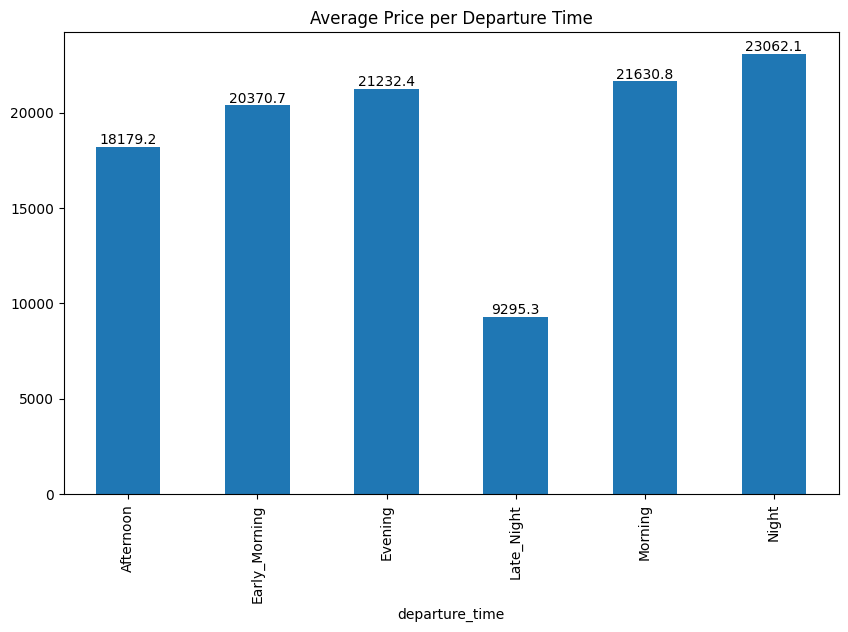

In [31]:
# Average price per departire tim

avg_price_departure = df.groupby('departure_time')['price'].mean()

ax = avg_price_departure.plot(kind='bar', figsize=(10,6))
for container in ax.containers:
    ax.bar_label(container)
plt.title("Average Price per Departure Time")

Text(0.5, 1.0, 'Average Price per Source City to Destination City')

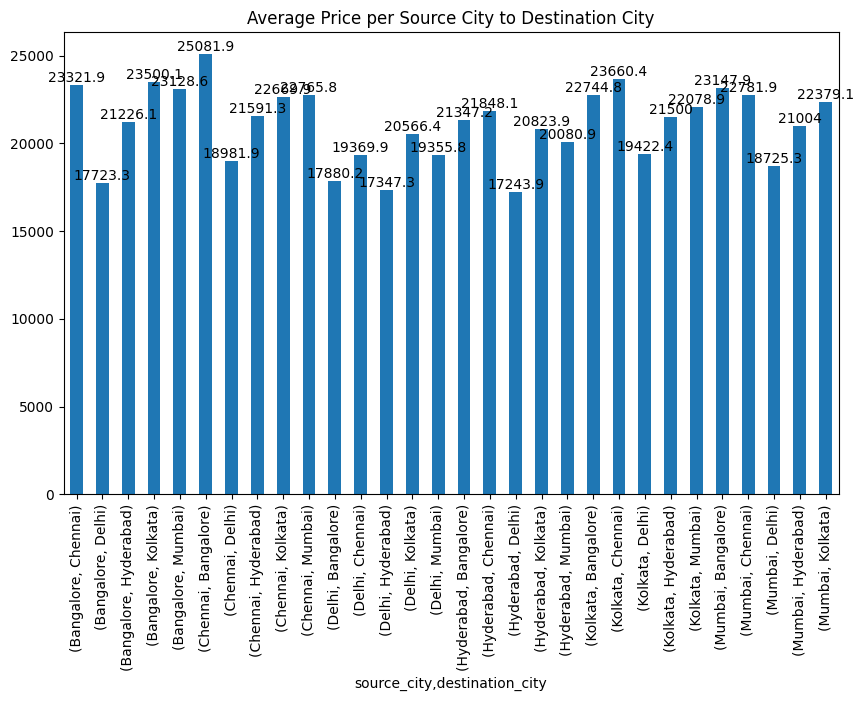

In [32]:
# Average price per source city to destination city

ave_price_source_to_destination = df.groupby(['source_city','destination_city'])['price'].mean()

ax = ave_price_source_to_destination.plot(kind='bar', figsize=(10,6))
for container in ax.containers:
    ax.bar_label(container)
plt.title("Average Price per Source City to Destination City")

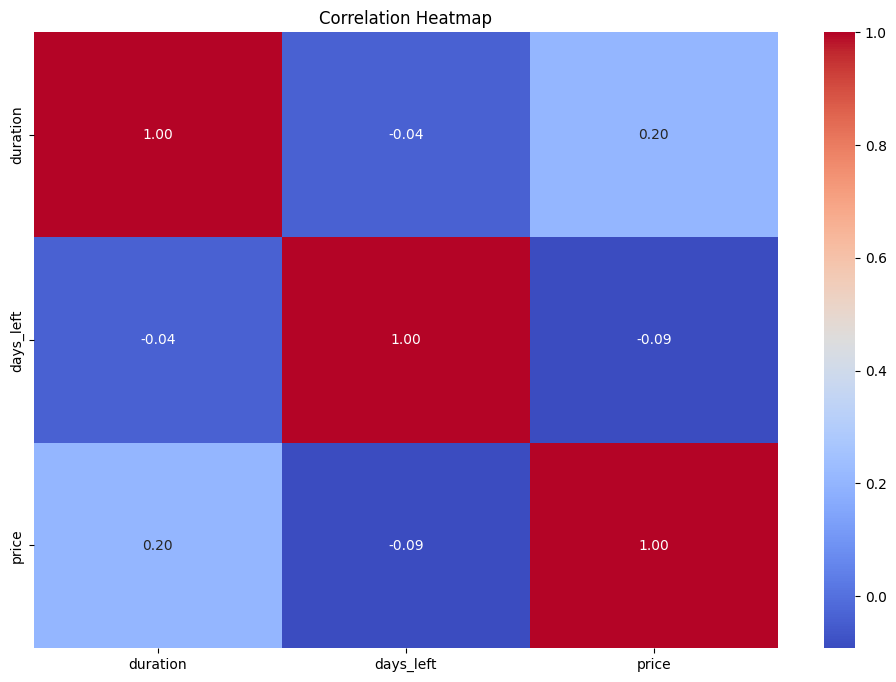

In [33]:
# Correlation matrix

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

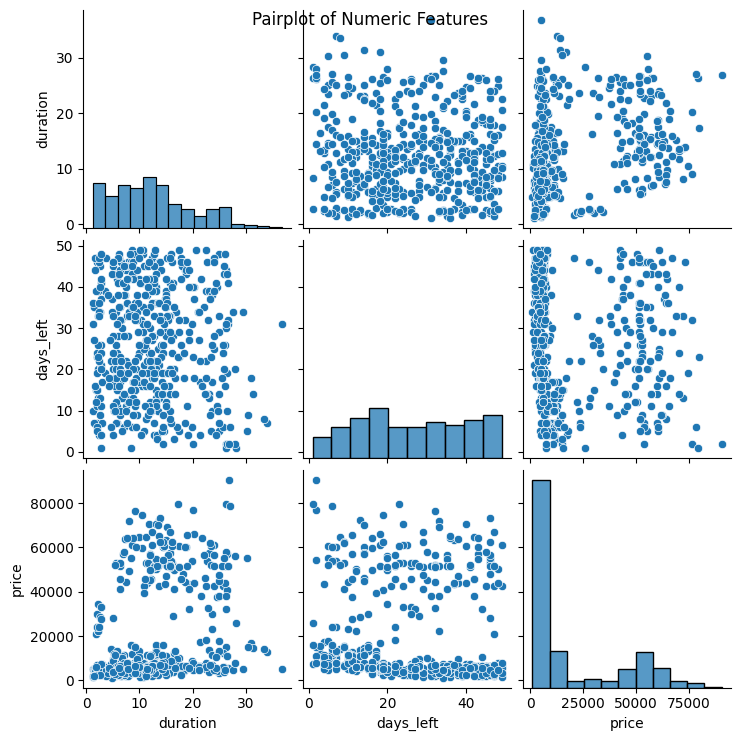

In [34]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols
sample_df = df[num_cols].sample(n=min(500, len(df)), random_state=42)
sns.pairplot(sample_df)
plt.suptitle("Pairplot of Numeric Features")
plt.show()

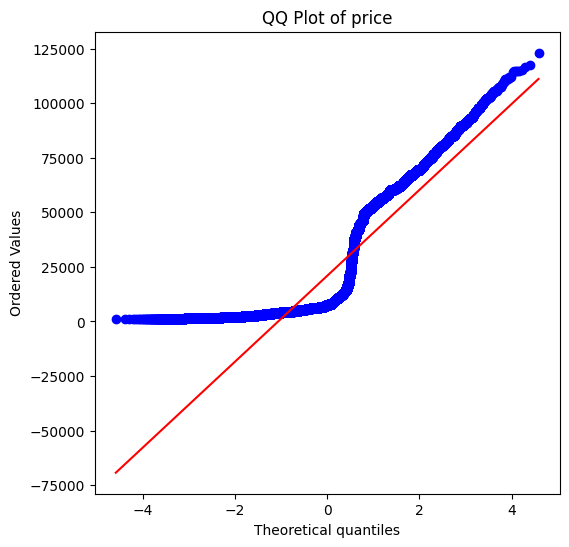

In [35]:
# QQ Plot

plt.figure(figsize=(6,6))
stats.probplot(df['price'].dropna(), dist="norm", plot=plt)
plt.title(f"QQ Plot of price")
plt.show()

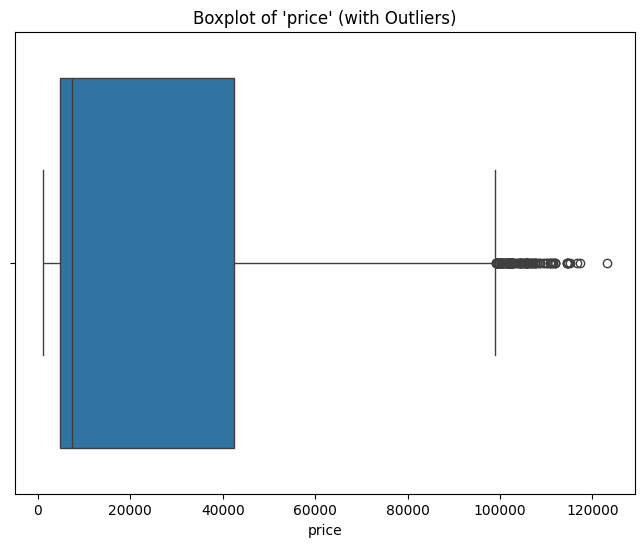

In [36]:
# Draw boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x=df['price'])
plt.title(f"Boxplot of 'price' (with Outliers)")
plt.show()

# Data Preprocessing

In [37]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [38]:
df.drop(columns=['flight'], inplace = True)

In [39]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  object 
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class             300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 22.9+ MB


In [41]:
# select the categorical columns

from sklearn.preprocessing import OneHotEncoder

cate_col = df.select_dtypes(include=['object']).columns.to_list()

cate_col

['airline',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class']

In [42]:
# Perform OneHotEncodding

final_df = pd.get_dummies(df, columns=cate_col).replace(True,1).replace(False,0)

final_df.head()

,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Bangalore,...,arrival_time_Morning,arrival_time_Night,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Business,class_Economy
0,2.17,1,5953,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,1
1,2.33,1,5953,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,0,1
2,2.17,1,5956,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
3,2.25,1,5955,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1
4,2.33,1,5955,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,1


# Feature selection

In [43]:
X = final_df.drop(columns=['price'])
y = final_df['price']

# model training


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [46]:
# make prediction

y_pred = lr.predict(X_test)

In [47]:
# chceck the accuracy score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_error

r2_score(y_test, y_pred)

0.9113048651706632

In [48]:
# check the MAE, MSE, R2 score, Root MSE

print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 4553.287816782337
MSE: 45720769.75632421
RMSE: 6761.713522201618


In [49]:
# apply the decision tree

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)


DecisionTreeRegressor()

In [50]:
# make the perdiction

y_pred = dt.predict(X_test)

In [51]:
# Check the accuracy, MAE, MSE, Root MSE

print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 1159.8143014997809
MSE: 12336480.778843895
R2 Score: 0.9760680795220485
RMSE: 3512.332669159329


In [52]:
# apply randomforest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [53]:
# make the prediction

y_pred = rf.predict(X_test)


In [54]:
# Check the accuracy, MAE, MSE, Root MSE

print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 Score:', r2_score(y_test, y_pred))

MAE: 1077.8998370896597
MSE: 7752807.051025514
RMSE: 2784.386297018701
R2 Score: 0.9849600899030921


# Hypothesis testing
Do direct flights have significantly lower prices than connecting flights?

In [55]:
from scipy.stats import ttest_ind

direct = final_df[final_df['stops_zero'] == 1]['price']
stops = final_df[(final_df['stops_one'] == 1) | (final_df['stops_two_or_more'] == 1)]['price']


t_stat, p_value = ttest_ind(direct, stops, equal_var=False)
print("T-test: Direct vs Stops")
print("t-stat:", t_stat, "p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference in prices between direct and stops flights.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in prices between direct and stops flights.")

T-test: Direct vs Stops
t-stat: -181.17561004089475 p-value: 0.0
Reject the null hypothesis. There is a significant difference in prices between direct and stops flights.
